# Ресерч: разбор данных и сбор кандидатов в признаки

Этот ноутбук **ничего не решает окончательно**. Его задача — пройти по данным поле за полем,
посчитать кандидатов в признаки и отранжировать их. Окончательный вердикт выносит
кросс-валидация в `solution.ipynb`, куда кандидаты переносятся группами.

## Три правила, которым подчинён весь ноутбук

**1. Окно.** События берутся строго в `[window_start_ts, window_end_ts)`. Функция фильтрации
скопирована из `solution.ipynb` дословно. Всё, что за правой границей окна, — информация из
будущего, включая `captcha_shown`, которого после фильтра физически не остаётся.

**2. Связь с target смотрим только по train.** В тесте меток нет. Тест используется ровно
для одного — проверить, что распределение кандидата не уехало между периодами.

**3. Скрининг делится по времени.** Сила каждого кандидата считается отдельно на ранних днях
(06–12) и на поздних (13–19). Признак засчитывается, только если он силён на ранних днях
**и** подтвердился на поздних. Без этого правила мы бы отбирали признаки по тому, как удачно
они легли на шум, и потом удивлялись, почему кросс-валидация показывает больше, чем
лидерборд.

## Что уже известно из первого этапа

| | |
|---|---|
| базовая модель на 33 признаках | P@R≥0.7 = 0.5004 |
| шум метрики (bootstrap std) | 0.0410 |
| сдвиг train vs test | нет, adversarial AUC 0.5145 |

Число 0.0410 — цена деления. Любая группа признаков, которая даёт меньше, засчитана не будет.

In [1]:
# Настройки, импорты, загрузка. Дальше всё считается из ev_tr / ev_te, посчитанных здесь один раз.

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.metrics import roc_auc_score

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

train = pd.read_csv(DATA_DIR / "train.csv",
                    parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(DATA_DIR / "test.csv",
                   parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(DATA_DIR / "events.csv.gz", parse_dates=["event_ts"])

# ----------------------------------------------------------------------------------
# КОПИЯ из solution.ipynb. Менять здесь нельзя: если две версии разойдутся, ресерч
# начнёт изучать не те данные, на которых потом учится модель. При слиянии этапов
# обе функции переедут в общий модуль, и копия исчезнет.
# ----------------------------------------------------------------------------------
EVENT_NAMES = [
    "search_results_view", "item_view", "photo_swipe", "seller_page_view",
    "contact_phone_show", "contact_chat_open", "contact_message_sent",
    "favorite_add", "login",
]


def normalize_platform(s):
    out = s.astype("string").str.lower()
    return out.replace({"iphone": "ios"})


def clip_to_window(events_raw, meta):
    ev = events_raw.merge(
        meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id", how="inner"
    )
    keep = (ev["event_ts"] >= ev["window_start_ts"]) & (ev["event_ts"] < ev["window_end_ts"])
    ev = ev.loc[keep].copy()
    ev = ev.sort_values(["cookie_id", "event_ts"], kind="mergesort").reset_index(drop=True)
    ev["platform_norm"] = normalize_platform(ev["platform"])
    assert (ev["event_name"] == "captcha_shown").sum() == 0, "после фильтра не должно остаться captcha_shown"
    return ev
# ----------------------------------------------------------------------------------

ev_tr = clip_to_window(events, train)
ev_te = clip_to_window(events, test)

# метка для каждой куки train — нужна во всех срезах ниже
lab = train.set_index("cookie_id")["target"]
ev_tr["target"] = ev_tr["cookie_id"].map(lab).astype(int)

BASE_RATE = train["target"].mean()

print("событий в окне: train", len(ev_tr), " test", len(ev_te))
print("кук: train", train["cookie_id"].nunique(), " test", test["cookie_id"].nunique())
print("доля ботов в train:", round(BASE_RATE, 4))
print("окна train:", train["window_start_ts"].min().date(), "—", train["window_start_ts"].max().date())
print("окна test :", test["window_start_ts"].min().date(), "—", test["window_start_ts"].max().date())

событий в окне: train 198436  test 89690
кук: train 11091  test 4909
доля ботов в train: 0.0811
окна train: 2026-04-06 — 2026-04-19
окна test : 2026-04-20 — 2026-04-26


## Часть 1. Паспорт полей

Прежде чем что-то считать, смотрим на сырьё: что за поле, сколько в нём разных значений,
насколько оно заполнено — и **отдельно заполненность у ботов и у людей**.

Последняя колонка — самостоятельный сигнал. Если поле систематически пустует у одной из
групп, это уже признак, даже если само содержимое поля ничего не даёт.

In [2]:
# Паспорт всех колонок событий.

rows = []
for col in ev_tr.columns:
    if col in ("target", "window_start_ts", "window_end_ts", "platform_norm"):
        continue
    fill_bot = ev_tr.loc[ev_tr.target == 1, col].notna().mean()
    fill_hum = ev_tr.loc[ev_tr.target == 0, col].notna().mean()
    rows.append({
        "поле": col,
        "тип": str(ev_tr[col].dtype),
        "уникальных": ev_tr[col].nunique(),
        "заполнено": round(ev_tr[col].notna().mean(), 3),
        "заполнено у людей": round(fill_hum, 3),
        "заполнено у ботов": round(fill_bot, 3),
        "разница бот-человек": round(fill_bot - fill_hum, 3),
    })

passport = pd.DataFrame(rows).sort_values("разница бот-человек", key=abs, ascending=False)
print("Паспорт полей (отсортирован по тому, насколько по-разному поле заполнено у ботов и людей):")
display(passport)

Паспорт полей (отсортирован по тому, насколько по-разному поле заполнено у ботов и людей):


,поле,тип,уникальных,заполнено,заполнено у людей,заполнено у ботов,разница бот-человек
12,pointer_x,float64,1921,0.334,0.347,0.246,-0.101
13,pointer_y,float64,1081,0.334,0.347,0.246,-0.101
10,search_query,object,120,0.311,0.305,0.352,0.047
11,search_page,float64,43,0.311,0.305,0.352,0.047
6,item_id,float64,46953,0.669,0.674,0.641,-0.033
9,seller_type,object,2,0.609,0.612,0.584,-0.028
8,item_location,object,40,0.950,0.949,0.962,0.013
7,item_category,object,15,0.921,0.920,0.931,0.011
0,cookie_id,object,11091,1.000,1.000,1.000,0.000
1,event_ts,datetime64[ns],178059,1.000,1.000,1.000,0.000


## Часть 2.1. Время событий — ожидается главный источник сигнала

Человек кликает рвано: задумался, отвлёкся, ушёл пить чай. Робот работает ровно.
Поэтому смотрим не на среднее время между событиями, а на **равномерность** ритма
и на то, как активность размазана по суткам.

Ключевая величина — коэффициент вариации интервалов (`std / mean`). У ровного ритма он мал,
у человеческого — велик. Это устойчивее к скорости, чем сама скорость: медленный робот
всё равно остаётся ровным.

Интервалы между соседними событиями, секунды:


,count,mean,std,min,10%,25%,50%,75%,90%,max
target,,,,,,,,,,
0,161737.0,732.3,1892.0,0.0,7.0,19.0,46.0,117.0,3107.0,9760.0
1,25608.0,424.2,1479.0,0.0,4.0,7.0,14.0,35.0,372.3,9608.0



Поведение ритма в разрезе метки (медианы по кукам):


,dt_mean,dt_std,dt_median,dt_max,frac_lt_1s,frac_lt_5s,dt_cv
target,,,,,,,
0,657.294,1732.920,59.0,5893.0,0.0,0.00,2.064
1,425.407,1368.461,25.0,6035.0,0.0,0.04,2.616


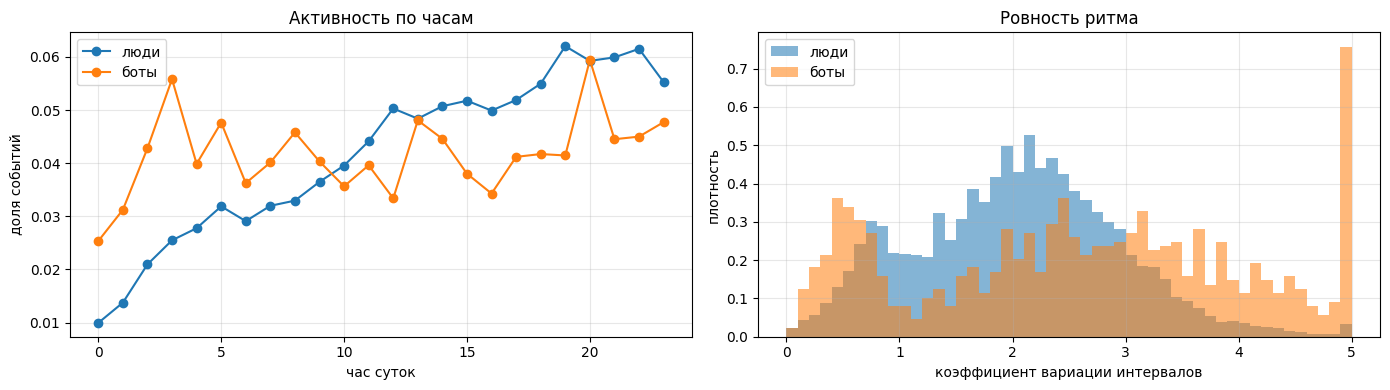

Доля ночных событий (часы 0-5):


target
0    0.1298
1    0.2428
Name: night, dtype: float64

In [3]:
# Ритм: интервалы между событиями и распределение активности по часам.

d = ev_tr.copy()
d["dt"] = d.groupby("cookie_id")["event_ts"].diff().dt.total_seconds()
dd = d.dropna(subset=["dt"])

print("Интервалы между соседними событиями, секунды:")
display(dd.groupby("target")["dt"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

g = dd.groupby("cookie_id")
rhythm = pd.DataFrame({
    "dt_mean": g["dt"].mean(),
    "dt_std": g["dt"].std(),
    "dt_median": g["dt"].median(),
    "dt_max": g["dt"].max(),
    "frac_lt_1s": g["dt"].apply(lambda s: (s < 1).mean()),
    "frac_lt_5s": g["dt"].apply(lambda s: (s < 5).mean()),
})
rhythm["dt_cv"] = rhythm["dt_std"] / rhythm["dt_mean"].clip(lower=1e-9)
rhythm["target"] = rhythm.index.map(lab)

print("\nПоведение ритма в разрезе метки (медианы по кукам):")
display(rhythm.groupby("target").median().round(3))

# сколько событий приходится на каждый час суток — у людей ожидаем ночной провал
byhour = ev_tr.assign(h=ev_tr["event_ts"].dt.hour).groupby(["target", "h"]).size().unstack(0)
byhour = byhour / byhour.sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(byhour.index, byhour[0], marker="o", label="люди")
ax[0].plot(byhour.index, byhour[1], marker="o", label="боты")
ax[0].set_xlabel("час суток"); ax[0].set_ylabel("доля событий")
ax[0].set_title("Активность по часам"); ax[0].legend(); ax[0].grid(alpha=0.3)

for t, nm in [(0, "люди"), (1, "боты")]:
    ax[1].hist(rhythm.loc[rhythm.target == t, "dt_cv"].clip(0, 5), bins=50,
               alpha=0.55, density=True, label=nm)
ax[1].set_xlabel("коэффициент вариации интервалов"); ax[1].set_ylabel("плотность")
ax[1].set_title("Ровность ритма"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Доля ночных событий (часы 0-5):")
display(ev_tr.assign(night=ev_tr["event_ts"].dt.hour < 6).groupby("target")["night"].mean().round(4))

## Часть 2.2. user_agent — самое недоиспользованное поле

В базовой модели из user_agent берётся ровно одно число: сколько разных строк у куки.
А внутри 148 уникальных строк лежат и явные клиенты-скраперы, и обычные браузеры,
и мобильное приложение Авито.

Разбираем регуляркой — внешние библиотеки вроде `ua-parser` не нужны, строк всего 148
и они шаблонные. Никаких языковых моделей здесь нет и не требуется.

Важно: явные клиенты (`curl`, `Scrapy`) — **не готовый ответ**. По первому этапу у них
доля ботов 25–33% при базовых 8%. Это сильный признак, но далеко не детерминированный:
большинство ботов маскируется под нормальные браузеры.

In [4]:
# Разбор user_agent на составляющие.

SCRAPER_CLIENTS = ["Scrapy", "curl", "node-fetch", "urllib3", "requests", "Go-http-client"]


def ua_family(s):
    """Чем именно сделан запрос. Порядок проверок важен: YaBrowser и Edge тоже содержат Chrome."""
    for c in SCRAPER_CLIENTS:
        if c in s:
            return "client_" + c.lower().replace("-", "_")
    if "okhttp" in s:
        return "avito_app"
    if "YaBrowser" in s:
        return "yabrowser"
    if "Edg/" in s:
        return "edge"
    if "OPR/" in s:
        return "opera"
    if "Firefox" in s:
        return "firefox"
    if "Chrome" in s:
        return "chrome"
    if "Safari" in s:
        return "safari"
    return "other"


def ua_os(s):
    if "Windows NT" in s:
        return "windows"
    if "Macintosh" in s or "Mac OS X" in s:
        return "macos"
    if "X11" in s:
        return "linux_x11"
    if "Android" in s:
        return "android"
    if "iPhone" in s or "iPad" in s:
        return "ios"
    if "Linux" in s:
        return "linux_other"
    return "unknown"


def ua_version(s):
    """Главный номер версии браузера или клиента — старые версии подозрительнее."""
    for pat in [r"Chrome/(\d+)", r"Firefox/(\d+)", r"Version/(\d+)", r"Avito/(\d+)",
                r"Scrapy/(\d+)", r"curl/(\d+)", r"node-fetch/(\d+)",
                r"urllib3/(\d+)", r"requests/(\d+)", r"Go-http-client/(\d+)"]:
        m = re.search(pat, s)
        if m:
            return float(m.group(1))
    return np.nan


ua_list = pd.Series(events["user_agent"].unique(), name="user_agent")
ua_map = pd.DataFrame({
    "user_agent": ua_list.values,
    "ua_family": [ua_family(s) for s in ua_list],
    "ua_os": [ua_os(s) for s in ua_list],
    "ua_ver": [ua_version(s) for s in ua_list],
})
ua_map["ua_is_client"] = ua_map["ua_family"].str.startswith("client_").astype(int)

print("Как разобрались", len(ua_map), "строк user_agent:")
display(ua_map.groupby(["ua_family", "ua_os"]).size().rename("строк UA").reset_index())

# доля ботов в разрезе разобранных признаков — по КУКАМ, не по событиям
ck = ev_tr.groupby("cookie_id").agg(user_agent=("user_agent", "first"), target=("target", "first")).reset_index()
ck = ck.merge(ua_map, on="user_agent", how="left")

for col in ["ua_family", "ua_os"]:
    t = ck.groupby(col)["target"].agg(["mean", "size"]).sort_values("mean", ascending=False)
    t["во сколько раз выше базы"] = (t["mean"] / BASE_RATE).round(2)
    t.columns = ["доля ботов", "кук", "во сколько раз выше базы"]
    print(f"\nДоля ботов по {col} (база {BASE_RATE:.3f}):")
    display(t.round(4))

# частота UA в популяции: редкий UA подозрительнее
ua_pop = events["user_agent"].value_counts(normalize=True).rename("ua_freq")
ck = ck.merge(ua_pop, left_on="user_agent", right_index=True, how="left")
ck["ua_freq_bucket"] = pd.qcut(ck["ua_freq"], 5,
                               labels=["очень редкий", "редкий", "средний", "частый", "очень частый"])
print("\nДоля ботов по редкости user_agent:")
display(ck.groupby("ua_freq_bucket", observed=True)["target"].agg(["mean", "size"]).round(4))

print("\nСколько разных user_agent у куки за сутки:")
nua = ev_tr.groupby("cookie_id").agg(n_ua=("user_agent", "nunique"), target=("target", "first"))
display(nua.groupby("target")["n_ua"].value_counts(normalize=True).unstack().round(4))

Как разобрались 148 строк user_agent:


,ua_family,ua_os,строк UA
0,avito_app,android,27
1,chrome,android,48
2,chrome,linux_x11,4
3,chrome,macos,14
4,chrome,windows,14
5,client_curl,unknown,1
6,client_go_http_client,unknown,1
7,client_node_fetch,unknown,1
8,client_requests,unknown,1
9,client_scrapy,unknown,1



Доля ботов по ua_family (база 0.081):


,доля ботов,кук,во сколько раз выше базы
ua_family,,,
client_node_fetch,0.2727,33,3.36
client_scrapy,0.2571,35,3.17
client_curl,0.2500,32,3.08
client_urllib3,0.1935,31,2.39
client_requests,0.1852,27,2.28
client_go_http_client,0.1667,42,2.06
avito_app,0.1026,1754,1.27
firefox,0.0866,1432,1.07
yabrowser,0.0833,1212,1.03



Доля ботов по ua_os (база 0.081):


,доля ботов,кук,во сколько раз выше базы
ua_os,,,
linux_x11,0.2622,286,3.24
unknown,0.2200,200,2.71
windows,0.0879,4049,1.08
macos,0.0775,1574,0.96
android,0.0620,4595,0.77
ios,0.0439,387,0.54



Доля ботов по редкости user_agent:


,mean,size
ua_freq_bucket,,
очень редкий,0.0511,2272
редкий,0.0543,2228
средний,0.1105,2218
частый,0.0827,2347
очень частый,0.1101,2026



Сколько разных user_agent у куки за сутки:


n_ua,1,2,3
target,,,
0,0.9269,0.0104,0.0627
1,0.9433,0.0011,0.0556


## Часть 2.3. Платформа

В сырых данных одно и то же записано в разном регистре, и без нормализации любой счётчик
по платформе — мусор. После приведения остаётся четыре значения: desktop, web, android, ios.

Базовая модель знает только «сколько разных платформ у куки», но не знает, **каких именно**.
Проверяем, есть ли разница в самих платформах и в переключениях между ними.

In [5]:
# Платформа: регистровые дубли, доли и переключения.

print("Сырые значения platform (видны регистровые дубли):")
display(events["platform"].value_counts().rename("событий"))
print("\nПосле нормализации:")
display(ev_tr["platform_norm"].value_counts().rename("событий"))

pl = pd.crosstab(ev_tr["cookie_id"], ev_tr["platform_norm"], normalize="index")
pl["target"] = pl.index.map(lab)
print("\nСредняя доля событий на каждой платформе, в разрезе метки:")
display(pl.groupby("target").mean().round(4))

# переключения платформы внутри суток
sw = ev_tr.copy()
sw["prev"] = sw.groupby("cookie_id")["platform_norm"].shift()
sw["switch"] = (sw["prev"].notna()) & (sw["prev"] != sw["platform_norm"])
sws = sw.groupby("cookie_id").agg(switch_frac=("switch", "mean"), target=("target", "first"))
print("\nДоля переходов со сменой платформы:")
display(sws.groupby("target")["switch_frac"].describe().round(4))

Сырые значения platform (видны регистровые дубли):


platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: событий, dtype: int64


После нормализации:


platform_norm
web        82152
android    77991
desktop    27855
ios        10438
Name: событий, dtype: Int64


Средняя доля событий на каждой платформе, в разрезе метки:


platform_norm,android,desktop,ios,web
target,,,,
0,0.4229,0.1325,0.0543,0.3903
1,0.3170,0.1653,0.0289,0.4887



Доля переходов со сменой платформы:


,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,10192.0,0.1666,0.2035,0.0,0.0,0.0,0.3333,0.875
1,899.0,0.2285,0.1992,0.0,0.0,0.2791,0.3886,0.875


## Часть 2.4. Навигация по выдаче

Гипотеза простая: человек смотрит первые страницы и уходит, скрапер идёт вглубь и по порядку.

Отдельно проверяем **монотонность**: доля шагов, где номер страницы увеличился ровно на единицу.
Обход выдачи подряд (1, 2, 3, 4) даёт долю близкую к единице, человек же скачет и возвращается.
Это интереснее, чем просто максимальная страница, потому что не зависит от того, сколько
человек успел посмотреть.

Распределение номера страницы выдачи:


,count,mean,std,min,50%,75%,90%,99%,max
target,,,,,,,,,
0,52399.0,2.56,2.16,1.0,2.0,3.0,5.0,11.0,33.0
1,9318.0,4.68,4.78,1.0,3.0,6.0,11.0,23.0,63.0



Навигация в разрезе метки (медианы):


,page_max,page_mean,page_gt5,page_gt10,step_plus1_frac
target,,,,,
0,4.0,2.0000,0.0000,0.0,0.0000
1,7.0,3.1909,0.1429,0.0,0.0392


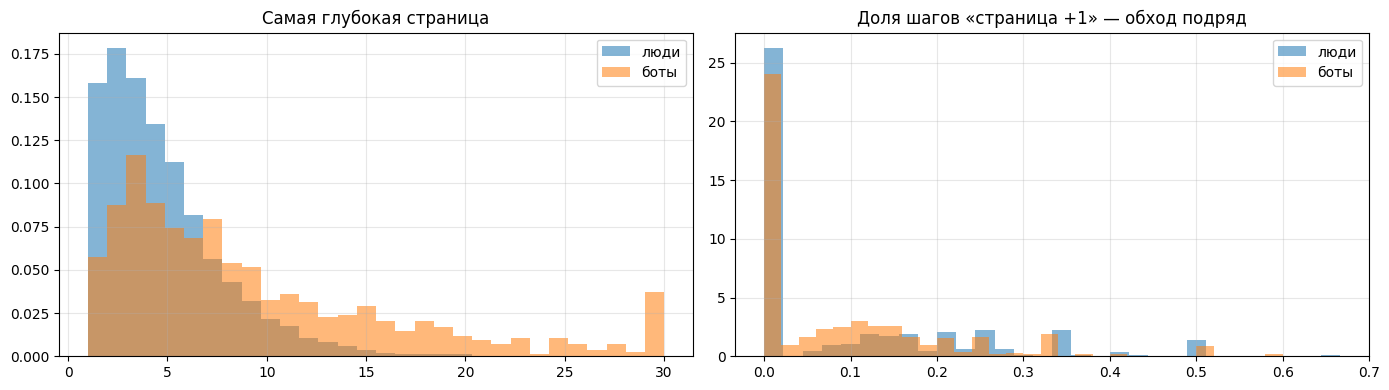

In [6]:
# Глубина и порядок обхода выдачи.

sr = ev_tr[ev_tr["event_name"] == "search_results_view"].copy()
print("Распределение номера страницы выдачи:")
display(sr.groupby("target")["search_page"].describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(2))

sr["prev_page"] = sr.groupby("cookie_id")["search_page"].shift()
sr["step_plus1"] = (sr["search_page"] - sr["prev_page"]) == 1

nav = sr.groupby("cookie_id").agg(
    page_max=("search_page", "max"),
    page_mean=("search_page", "mean"),
    page_gt5=("search_page", lambda s: (s > 5).mean()),
    page_gt10=("search_page", lambda s: (s > 10).mean()),
    step_plus1_frac=("step_plus1", "mean"),
    target=("target", "first"),
)
print("\nНавигация в разрезе метки (медианы):")
display(nav.groupby("target").median().round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for t, nm in [(0, "люди"), (1, "боты")]:
    ax[0].hist(nav.loc[nav.target == t, "page_max"].clip(0, 30), bins=30, alpha=0.55, density=True, label=nm)
    ax[1].hist(nav.loc[nav.target == t, "step_plus1_frac"].dropna(), bins=30, alpha=0.55, density=True, label=nm)
ax[0].set_title("Самая глубокая страница"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_title("Доля шагов «страница +1» — обход подряд"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Часть 2.5. Поисковые запросы

Важное наблюдение из разведки: **уникальных запросов всего 120, и они примерно одинаково
популярны** — по 900 показов каждый. Значит содержание запроса само по себе ничего не говорит,
и кодировать текст бессмысленно.

Смотреть надо на поведение вокруг запроса: сколько разных запросов, сколько страниц на запрос,
доля повторов и — самое интересное — **доля запросов, после которых кука не открыла ни одной
карточки**. Человек ищет, чтобы что-то посмотреть; сборщик выдачи может обходиться без этого.

In [7]:
# Поведение вокруг поисковых запросов.

print("Длина запроса в символах:")
display(sr.groupby("target")["search_query"].apply(lambda s: s.dropna().str.len().mean()).round(2).rename("средняя длина"))

q = sr.groupby("cookie_id").agg(
    n_searches=("search_query", "size"),
    n_queries_uniq=("search_query", "nunique"),
    target=("target", "first"),
)
q["pages_per_query"] = q["n_searches"] / q["n_queries_uniq"].clip(lower=1)
q["query_repeat_frac"] = 1 - q["n_queries_uniq"] / q["n_searches"].clip(lower=1)

# сколько просмотров карточек приходится на один поиск
views = ev_tr[ev_tr["event_name"] == "item_view"].groupby("cookie_id").size().rename("n_views")
q = q.join(views).fillna({"n_views": 0})
q["views_per_search"] = q["n_views"] / q["n_searches"].clip(lower=1)

print("\nПоведение вокруг запросов (медианы):")
display(q.groupby("target")[["n_searches", "n_queries_uniq", "pages_per_query",
                             "query_repeat_frac", "views_per_search"]].median().round(4))

Длина запроса в символах:


target
0    13.23
1    13.38
Name: средняя длина, dtype: float64


Поведение вокруг запросов (медианы):


,n_searches,n_queries_uniq,pages_per_query,query_repeat_frac,views_per_search
target,,,,,
0,4.0,3.0,1.0,0.0000,1.0526
1,7.0,4.0,1.5,0.3333,1.2500


## Часть 2.6. Товары, категории, локации, тип продавца

Ещё одно наблюдение из разведки: **15 категорий распределены почти поровну** (по 19–20 тысяч
событий), локации тоже. Значит target encoding по категориям бесполезен — сигнала в самих
значениях нет.

Смысл есть в **структуре внутри куки**: насколько кука сконцентрирована на одной категории
(энтропия и доля самой частой), как часто переключается между категориями, и сколько раз
возвращается к одному и тому же товару.

`seller_type` в базовой модели не используется вообще. Проверяем гипотезу: сборщику контактов
интереснее частные объявления, чем профессиональные.

In [8]:
# Концентрация против разбросанности.


def entropy_of(s):
    """Насколько равномерно кука размазана по значениям. 0 — сидит в одном, выше — разбрасывается."""
    p = s.value_counts(normalize=True)
    return float(-(p * np.log(p)).sum())


cat = ev_tr.dropna(subset=["item_category"]).groupby("cookie_id").agg(
    cat_entropy=("item_category", entropy_of),
    cat_top_frac=("item_category", lambda s: s.value_counts(normalize=True).max()),
    cat_nuniq=("item_category", "nunique"),
    target=("target", "first"),
)
loc = ev_tr.dropna(subset=["item_location"]).groupby("cookie_id").agg(
    loc_entropy=("item_location", entropy_of),
    loc_top_frac=("item_location", lambda s: s.value_counts(normalize=True).max()),
    loc_nuniq=("item_location", "nunique"),
)
print("Концентрация по категориям и локациям (медианы):")
display(cat.join(loc).groupby("target").median().round(4))

# повторные обращения к одному товару
it = ev_tr.dropna(subset=["item_id"]).groupby("cookie_id").agg(
    n_item_events=("item_id", "size"),
    n_items_uniq=("item_id", "nunique"),
    target=("target", "first"),
)
it["item_repeat_frac"] = 1 - it["n_items_uniq"] / it["n_item_events"]
print("\nПовторные обращения к одному товару:")
display(it.groupby("target")[["n_item_events", "n_items_uniq", "item_repeat_frac"]].median().round(4))

# популярность товара в популяции: считается по всем кукам, метки не используются — утечки нет
ev_all = pd.concat([ev_tr.drop(columns="target"), ev_te], ignore_index=True)
item_pop = ev_all.dropna(subset=["item_id"]).groupby("item_id")["cookie_id"].nunique().rename("item_pop")
tmp = ev_tr.dropna(subset=["item_id"]).merge(item_pop, on="item_id", how="left")
print("\nСредняя популярность товаров, которые трогает кука:")
display(tmp.groupby("cookie_id").agg(item_pop_mean=("item_pop", "mean"),
                                     target=("target", "first")).groupby("target").median().round(3))

# тип продавца
st = pd.crosstab(ev_tr["cookie_id"], ev_tr["seller_type"], normalize="index")
st["target"] = st.index.map(lab)
print("\nДоли типов продавца у куки:")
display(st.groupby("target").mean().round(4))

Концентрация по категориям и локациям (медианы):


,cat_entropy,cat_top_frac,cat_nuniq,loc_entropy,loc_top_frac,loc_nuniq
target,,,,,,
0,0.6365,0.6897,2.0,1.2130,0.5000,5.0
1,0.4101,0.8571,2.0,1.8344,0.3333,8.0



Повторные обращения к одному товару:


,n_item_events,n_items_uniq,item_repeat_frac
target,,,
0,8.0,6.0,0.2
1,13.0,10.0,0.2



Средняя популярность товаров, которые трогает кука:


,item_pop_mean
target,
0,3.625
1,6.400



Доли типов продавца у куки:


seller_type,private,pro
target,,
0,0.5893,0.4107
1,0.5473,0.4527


## Часть 2.7. Координаты указателя

Разведка показала важное: координаты глобально **равномерны** по экрану 1920×1080.
Доля значений, кратных 5 — 20.3%, кратных 10 — 10.4%, ровно как у равномерного распределения.
Общей «сетки бота» в данных нет, искать её бессмысленно.

Поэтому смотрим не на глобальную форму, а на поведение внутри куки: насколько вообще
проставлены координаты, повторяются ли точки, какой разброс и какие расстояния между
соседними точками. Отсутствие координат само по себе может быть сильнее их содержания.

Доля событий с координатами, по типам событий и метке:


target,0,1
event_name,,
contact_chat_open,0.332,0.152
contact_message_sent,0.346,0.148
contact_phone_show,0.348,0.133
favorite_add,0.354,0.308
item_view,0.345,0.248
login,0.362,0.285
photo_swipe,0.348,0.285
search_results_view,0.347,0.247
seller_page_view,0.359,0.229



Поведение координат внутри куки (медианы):


,ptr_n,ptr_x_std,ptr_y_std,ptr_dist_mean,ptr_repeat_frac
target,,,,,
0,11.0,552.050,308.073,778.668,0.0
1,19.0,200.551,200.970,360.073,0.0


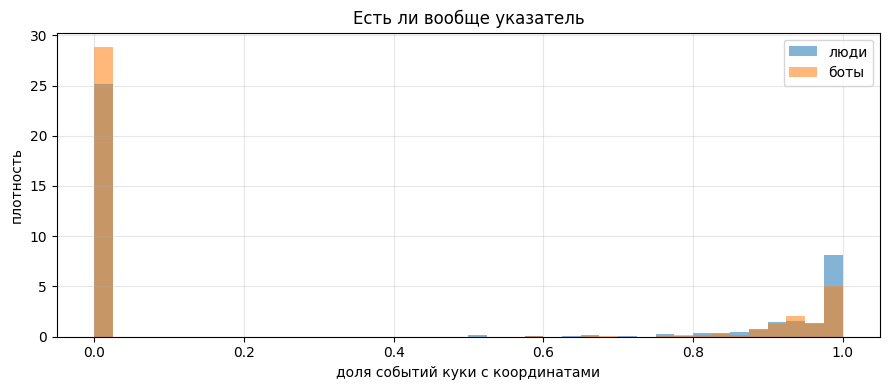

In [9]:
# Координаты: наличие, разброс, повторы.

print("Доля событий с координатами, по типам событий и метке:")
display(pd.crosstab(ev_tr["event_name"], ev_tr["target"],
                    values=ev_tr["pointer_x"].notna(), aggfunc="mean").round(3))

p = ev_tr.dropna(subset=["pointer_x", "pointer_y"]).copy()
p["dist"] = np.sqrt(
    p.groupby("cookie_id")["pointer_x"].diff() ** 2 + p.groupby("cookie_id")["pointer_y"].diff() ** 2
)
p["xy"] = p["pointer_x"].astype(int).astype(str) + "_" + p["pointer_y"].astype(int).astype(str)

ptr = p.groupby("cookie_id").agg(
    ptr_n=("pointer_x", "size"),
    ptr_x_std=("pointer_x", "std"),
    ptr_y_std=("pointer_y", "std"),
    ptr_xy_uniq=("xy", "nunique"),
    ptr_dist_mean=("dist", "mean"),
    target=("target", "first"),
)
ptr["ptr_repeat_frac"] = 1 - ptr["ptr_xy_uniq"] / ptr["ptr_n"]
print("\nПоведение координат внутри куки (медианы):")
display(ptr.groupby("target")[["ptr_n", "ptr_x_std", "ptr_y_std",
                               "ptr_dist_mean", "ptr_repeat_frac"]].median().round(3))

# доля событий с координатами на уровне куки — это и есть главный кандидат из этой группы
frac = ev_tr.groupby("cookie_id").agg(ptr_frac=("pointer_x", lambda s: s.notna().mean()),
                                      target=("target", "first"))
fig, ax = plt.subplots(figsize=(9, 4))
for t, nm in [(0, "люди"), (1, "боты")]:
    ax.hist(frac.loc[frac.target == t, "ptr_frac"], bins=40, alpha=0.55, density=True, label=nm)
ax.set_xlabel("доля событий куки с координатами"); ax.set_ylabel("плотность")
ax.set_title("Есть ли вообще указатель"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Часть 3. Порядок событий и воронка

До сих пор мы считали события мешком: сколько чего было. Но у поведения есть порядок,
и он может отличать сборщика от покупателя сильнее, чем любые счётчики.

Смотрим две вещи. Первая — **матрица переходов**: из какого события в какое чаще всего идёт
кука. Вторая — **глубина воронки**: поиск → карточка → фото → контакт. Покупатель проходит
её целиком, сборщик контактов перескакивает через фото, сборщик выдачи не доходит и до карточки.

In [10]:
# Переходы между типами событий и полнота воронки.

s = ev_tr[["cookie_id", "event_name", "target"]].copy()
s["next_event"] = s.groupby("cookie_id")["event_name"].shift(-1)
s = s.dropna(subset=["next_event"])

for t, nm in [(0, "люди"), (1, "боты")]:
    m = pd.crosstab(s.loc[s.target == t, "event_name"], s.loc[s.target == t, "next_event"], normalize="index")
    print(f"\nКуда переходит {nm} (доля строк, читать по строкам):")
    display(m.round(3))

# разница матриц — сразу видно, какие переходы характерны для ботов
m0 = pd.crosstab(s.loc[s.target == 0, "event_name"], s.loc[s.target == 0, "next_event"], normalize="index")
m1 = pd.crosstab(s.loc[s.target == 1, "event_name"], s.loc[s.target == 1, "next_event"], normalize="index")
diff = (m1 - m0.reindex_like(m1)).round(3)
print("\nРазница «боты минус люди». Положительное — переход характерен для ботов:")
display(diff)

# глубина воронки
has = pd.crosstab(ev_tr["cookie_id"], ev_tr["event_name"]) > 0
funnel = pd.DataFrame({
    "шаг1_поиск": has.get("search_results_view", False),
    "шаг2_карточка": has.get("item_view", False),
    "шаг3_фото": has.get("photo_swipe", False),
    "шаг4_контакт": has.get("contact_phone_show", False) | has.get("contact_chat_open", False)
                    | has.get("contact_message_sent", False),
})
funnel["target"] = funnel.index.map(lab)
print("\nДоля кук, дошедших до каждого шага воронки:")
display(funnel.groupby("target").mean().round(4))

funnel["depth"] = funnel[["шаг1_поиск", "шаг2_карточка", "шаг3_фото", "шаг4_контакт"]].sum(axis=1)
print("\nРаспределение глубины воронки:")
display(funnel.groupby("target")["depth"].value_counts(normalize=True).unstack().round(4))


Куда переходит люди (доля строк, читать по строкам):


next_event,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
event_name,,,,,,,,,
contact_chat_open,0.034,0.010,0.036,0.069,0.350,0.023,0.129,0.289,0.061
contact_message_sent,0.023,0.027,0.047,0.070,0.349,0.018,0.115,0.300,0.051
contact_phone_show,0.023,0.012,0.059,0.068,0.356,0.024,0.116,0.293,0.050
favorite_add,0.020,0.011,0.037,0.084,0.354,0.021,0.122,0.296,0.056
item_view,0.020,0.010,0.035,0.062,0.377,0.021,0.121,0.302,0.052
login,0.020,0.010,0.032,0.071,0.347,0.036,0.135,0.293,0.055
photo_swipe,0.019,0.012,0.037,0.068,0.351,0.022,0.135,0.302,0.054
search_results_view,0.020,0.010,0.037,0.064,0.364,0.021,0.119,0.315,0.051
seller_page_view,0.020,0.011,0.040,0.065,0.362,0.021,0.122,0.298,0.062



Куда переходит боты (доля строк, читать по строкам):


next_event,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
event_name,,,,,,,,,
contact_chat_open,0.050,0.031,0.090,0.034,0.381,0.008,0.050,0.294,0.062
contact_message_sent,0.049,0.034,0.044,0.029,0.382,0.005,0.069,0.270,0.118
contact_phone_show,0.057,0.020,0.097,0.030,0.372,0.011,0.071,0.280,0.062
favorite_add,0.014,0.013,0.030,0.052,0.457,0.013,0.072,0.303,0.045
item_view,0.011,0.007,0.022,0.025,0.452,0.007,0.069,0.348,0.058
login,0.020,0.010,0.020,0.060,0.352,0.030,0.111,0.327,0.070
photo_swipe,0.016,0.008,0.027,0.026,0.414,0.009,0.103,0.340,0.058
search_results_view,0.012,0.006,0.019,0.026,0.433,0.007,0.065,0.376,0.056
seller_page_view,0.015,0.011,0.038,0.026,0.428,0.005,0.060,0.334,0.081



Разница «боты минус люди». Положительное — переход характерен для ботов:


next_event,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
event_name,,,,,,,,,
contact_chat_open,0.017,0.021,0.054,-0.035,0.031,-0.015,-0.079,0.006,0.001
contact_message_sent,0.026,0.008,-0.003,-0.041,0.033,-0.013,-0.046,-0.030,0.067
contact_phone_show,0.035,0.008,0.038,-0.038,0.016,-0.013,-0.045,-0.013,0.012
favorite_add,-0.006,0.002,-0.007,-0.032,0.103,-0.008,-0.050,0.007,-0.011
item_view,-0.008,-0.003,-0.014,-0.037,0.075,-0.013,-0.051,0.047,0.006
login,0.000,0.000,-0.012,-0.011,0.005,-0.006,-0.025,0.034,0.015
photo_swipe,-0.004,-0.004,-0.010,-0.042,0.063,-0.013,-0.032,0.038,0.004
search_results_view,-0.008,-0.003,-0.018,-0.039,0.069,-0.014,-0.053,0.061,0.005
seller_page_view,-0.005,0.000,-0.002,-0.038,0.066,-0.015,-0.062,0.036,0.019



Доля кук, дошедших до каждого шага воронки:


,шаг1_поиск,шаг2_карточка,шаг3_фото,шаг4_контакт
target,,,,
0,0.9133,0.9300,0.7303,0.4837
1,0.9588,0.9822,0.7319,0.5195



Распределение глубины воронки:


depth,0,1,2,3,4
target,,,,,
0,0.0049,0.0649,0.1897,0.3492,0.3914
1,0.0011,0.0211,0.1602,0.4194,0.3982


## Часть 3.5. Ловушка: популярность товара

Напрашивается признак «насколько популярны товары, которые трогала кука» — сколько других кук
обращалось к тем же объявлениям. Он действительно очень силён. И он же — главная ловушка
этого этапа.

Считать популярность по всем данным сразу нельзя. Для строки от 6 апреля в такую популярность
попадут куки от 26-го, то есть информация, которой на момент `window_end_ts` не существовало.
Правила требуют обратного, и лидерборд накажет за это молча.

Ниже признак считается двумя способами, и разница выводится числом. Честный вариант —
накопительный: для строки за конкретный день берутся только события **предыдущих** дней.
Побочный эффект: у самого первого дня истории нет вообще, и признак там нулевой. Это честно
и так и должно быть.

Та же логика применяется к частоте `user_agent` в популяции.

In [11]:
# Популяционные статистики строго по прошлому. Сравниваем с нечестным вариантом.

ev_all = pd.concat([ev_tr.drop(columns="target"), ev_te], ignore_index=True)
ev_all_i = ev_all.dropna(subset=["item_id"])

# Каждая кука живёт ровно в одном суточном окне, поэтому число разных кук на товар
# равно числу пар (товар, кука) — отдельно считать уникальность не нужно.
pairs = ev_all_i[["item_id", "cookie_id", "window_start_ts"]].drop_duplicates()
per_day = pairs.groupby(["item_id", "window_start_ts"]).size().unstack(fill_value=0).sort_index(axis=1)

pop_all = per_day.sum(axis=1)                                    # по всем дням, включая будущие
pop_before = per_day.cumsum(axis=1).shift(1, axis=1).fillna(0)   # только по прошлым дням


def _pop_auc(popmap, day_aware):
    """Считает признак и меряет его одномерный AUC на train."""
    e = ev_tr.dropna(subset=["item_id"])
    if day_aware:
        key = pd.MultiIndex.from_arrays([e["item_id"].values, e["window_start_ts"].values])
        vals = popmap.stack().reindex(key).values
    else:
        vals = e["item_id"].map(popmap).values
    s = pd.Series(vals, index=e["cookie_id"].values).groupby(level=0).mean()
    return roc_auc_score(lab.reindex(s.index), s.fillna(s.median()))


print("AUC признака «средняя популярность товаров, которые трогала кука»:")
print("   по всем дням, включая будущие:", round(_pop_auc(pop_all, False), 4), " <- так нельзя")
print("   только по прошлым дням       :", round(_pop_auc(pop_before, True), 4), " <- так можно")
print("\nРазница — это ровно то, сколько признак брал из будущего.")

# частота user_agent в популяции, тоже накопительно по прошлому
ua_pairs = ev_all[["user_agent", "cookie_id", "window_start_ts"]].drop_duplicates()
ua_per_day = ua_pairs.groupby(["user_agent", "window_start_ts"]).size().unstack(fill_value=0).sort_index(axis=1)
ua_before = ua_per_day.cumsum(axis=1).shift(1, axis=1).fillna(0)

# эти две переменные использует построитель признаков ниже
ITEM_POP_BEFORE = pop_before.stack()
UA_FREQ_BEFORE = (ua_before / ua_before.sum(axis=0).replace(0, np.nan)).stack()

print("\nСколько товаров уже имеют историю к началу дня:")
display(pd.Series({str(d.date()): int((pop_before[d] > 0).sum()) for d in per_day.columns},
                  name="товаров с историей").to_frame())

AUC признака «средняя популярность товаров, которые трогала кука»:
   по всем дням, включая будущие: 0.7859  <- так нельзя
   только по прошлым дням       : 0.6462  <- так можно

Разница — это ровно то, сколько признак брал из будущего.

Сколько товаров уже имеют историю к началу дня:


,товаров с историей
2026-04-06,0
2026-04-07,6378
2026-04-08,12391
2026-04-09,17836
2026-04-10,22716
2026-04-11,27527
2026-04-12,31320
2026-04-13,34332
2026-04-14,37062
2026-04-15,39548


## Часть 4. Сборка кандидатов и скрининг

Теперь всё, что разглядывали выше, считается одной функцией — по той же схеме, что и в
`solution.ipynb`: одна функция на train и test, чтобы признаки не разъехались.

Функция считает и **старые 33 признака**, и новых кандидатов. Старые нужны не для повторения,
а для колонки `corr_max`: если новый признак на 0.95 повторяет уже имеющийся, он не добавит
ничего, кроме шума, и тащить его не надо.

In [12]:
# Все кандидаты одной функцией. Группы помечены, чтобы потом переносить их в модель пачками.

# Популяционные статистики ITEM_POP_BEFORE и UA_FREQ_BEFORE берутся из ячейки выше.
# Они посчитаны ТОЛЬКО по прошлым дням — иначе признак заглядывает в будущее.
UA_INFO = ua_map.set_index("user_agent")

UA_FAMILIES = ["chrome", "firefox", "safari", "yabrowser", "avito_app"]
UA_OSES = ["windows", "macos", "linux_x11", "android", "ios"]
PLATFORMS = ["desktop", "web", "android", "ios"]
TRANSITIONS = [
    "search_results_view>search_results_view",
    "search_results_view>item_view",
    "item_view>photo_swipe",
    "item_view>item_view",
    "item_view>contact_phone_show",
    "item_view>seller_page_view",
]


def _ent(s):
    p = s.value_counts(normalize=True)
    return float(-(p * np.log(p)).sum()) if len(p) else np.nan


def build_candidates(meta, events_raw, desc="кандидаты"):
    """Считает старые 33 признака и всех новых кандидатов. Порядок строк — как в meta."""
    ev = clip_to_window(events_raw, meta)
    idx = pd.Index(meta["cookie_id"].values, name="cookie_id")
    F = pd.DataFrame(index=idx)
    groups = {}
    g = ev.groupby("cookie_id", sort=False)
    win_hours = (meta["window_end_ts"] - meta["window_start_ts"]).dt.total_seconds().values / 3600.0
    cookie_day = pd.Series(meta["window_start_ts"].values, index=meta["cookie_id"].values)

    def put(group, name, series):
        F[name] = series.reindex(idx) if isinstance(series, pd.Series) else series
        groups.setdefault(group, []).append(name)

    steps = ["база: объём", "база: счётчики", "база: ритм", "база: воронка", "база: навигация",
             "база: указатель", "база: техника", "база: мета", "новое: ритм", "новое: UA",
             "новое: платформа", "новое: навигация", "новое: запросы", "новое: содержимое",
             "новое: указатель", "новое: порядок"]
    pbar = tqdm(total=len(steps), desc=desc)

    def step(i):
        pbar.set_postfix_str(steps[i]); pbar.update(1)

    # ---------------- БАЗА: те же 33 признака, что уже в solution.ipynb ----------------
    put("base", "n_events", g.size())
    put("base", "n_items_uniq", g["item_id"].nunique())
    put("base", "n_cat_uniq", g["item_category"].nunique())
    put("base", "n_loc_uniq", g["item_location"].nunique())
    put("base", "n_query_uniq", g["search_query"].nunique())
    F["n_events"] = F["n_events"].fillna(0)
    F["events_per_hour"] = F["n_events"].values / win_hours
    groups["base"].append("events_per_hour")
    step(0)

    cnt = pd.crosstab(ev["cookie_id"], ev["event_name"]).reindex(columns=EVENT_NAMES, fill_value=0)
    cnt = cnt.reindex(idx).fillna(0.0)
    for c in EVENT_NAMES:
        put("base", "cnt_" + c, cnt[c])
    step(1)

    ev = ev.copy()
    ev["dt"] = g["event_ts"].diff().dt.total_seconds()
    dtd = ev.dropna(subset=["dt"])
    gd = dtd.groupby("cookie_id")["dt"]
    put("base", "dt_median", gd.median())
    put("base", "dt_min", gd.min())
    put("base", "dt_std", gd.std())
    put("base", "dt_frac_lt_1s", gd.apply(lambda s: (s < 1).mean()))
    put("base", "span_seconds", (g["event_ts"].max() - g["event_ts"].min()).dt.total_seconds())
    put("base", "n_active_hours", ev.assign(h=ev["event_ts"].dt.hour).groupby("cookie_id")["h"].nunique())
    step(2)

    views = F["cnt_item_view"].clip(lower=1)
    searches = F["cnt_search_results_view"].clip(lower=1)
    contacts = F["cnt_contact_phone_show"] + F["cnt_contact_chat_open"] + F["cnt_contact_message_sent"]
    put("base", "photo_per_view", F["cnt_photo_swipe"] / views)
    put("base", "contact_per_view", contacts / views)
    put("base", "view_per_search", F["cnt_item_view"] / searches)
    step(3)

    put("base", "max_search_page", g["search_page"].max())
    put("base", "mean_search_page", g["search_page"].mean())
    step(4)

    put("base", "ptr_frac", g["pointer_x"].apply(lambda s: s.notna().mean()))
    put("base", "ptr_x_nunique", g["pointer_x"].nunique())
    xy = ev.dropna(subset=["pointer_x", "pointer_y"]).copy()
    xy["_xy"] = xy["pointer_x"].astype(int).astype(str) + "_" + xy["pointer_y"].astype(int).astype(str)
    put("base", "ptr_xy_nunique", xy.groupby("cookie_id")["_xy"].nunique())
    F["ptr_xy_nunique"] = F["ptr_xy_nunique"].fillna(0.0)
    step(5)

    put("base", "n_platform_norm", g["platform_norm"].nunique())
    put("base", "n_user_agent", g["user_agent"].nunique())
    step(6)

    put("base", "cookie_age_days",
        (meta["window_end_ts"] - meta["cookie_created_at"]).dt.total_seconds().values / 86400.0)
    put("base", "window_dow", meta["window_start_ts"].dt.dayofweek.values.astype(float))
    step(7)

    # ---------------- НОВОЕ: ритм ----------------
    put("rhythm", "dt_mean", gd.mean())
    put("rhythm", "dt_max", gd.max())
    put("rhythm", "dt_p10", gd.quantile(0.10))
    put("rhythm", "dt_p90", gd.quantile(0.90))
    put("rhythm", "dt_frac_lt_5s", gd.apply(lambda s: (s < 5).mean()))
    F["dt_cv"] = F["dt_std"] / F["dt_mean"].clip(lower=1e-9)
    groups["rhythm"].append("dt_cv")

    # сессия начинается после паузы больше получаса
    ev["new_sess"] = ev["dt"].isna() | (ev["dt"] > 1800)
    ev["sess_id"] = ev.groupby("cookie_id")["new_sess"].cumsum()
    sess = ev.groupby(["cookie_id", "sess_id"]).size().rename("n").reset_index()
    put("rhythm", "n_sessions", sess.groupby("cookie_id")["sess_id"].max())
    put("rhythm", "sess_events_mean", sess.groupby("cookie_id")["n"].mean())
    put("rhythm", "sess_events_max", sess.groupby("cookie_id")["n"].max())
    put("rhythm", "hour_entropy", ev.assign(h=ev["event_ts"].dt.hour).groupby("cookie_id")["h"].apply(_ent))
    put("rhythm", "night_frac", ev.assign(n=(ev["event_ts"].dt.hour < 6).astype(float))
        .groupby("cookie_id")["n"].mean())
    step(8)

    # ---------------- НОВОЕ: user_agent ----------------
    ua_ck = ev.groupby("cookie_id")["user_agent"].agg(lambda s: s.mode().iat[0])
    ua_j = UA_INFO.reindex(ua_ck.values)
    put("ua", "ua_is_client", pd.Series(ua_j["ua_is_client"].values, index=ua_ck.index))
    put("ua", "ua_ver", pd.Series(ua_j["ua_ver"].values, index=ua_ck.index))
    _uk = pd.MultiIndex.from_arrays([ua_ck.values, cookie_day.reindex(ua_ck.index).values])
    put("ua", "ua_freq", pd.Series(UA_FREQ_BEFORE.reindex(_uk).values, index=ua_ck.index))
    for fam in UA_FAMILIES:
        put("ua", "ua_fam_" + fam,
            pd.Series((ua_j["ua_family"].values == fam).astype(float), index=ua_ck.index))
    for os_ in UA_OSES:
        put("ua", "ua_os_" + os_,
            pd.Series((ua_j["ua_os"].values == os_).astype(float), index=ua_ck.index))
    # UA говорит одно, platform другое — человек так не ходит
    plat_mode = ev.groupby("cookie_id")["platform_norm"].agg(lambda s: s.mode().iat[0])
    ua_os_ck = pd.Series(ua_j["ua_os"].values, index=ua_ck.index)
    expected = ua_os_ck.map({"android": "android", "ios": "ios",
                             "windows": "desktop", "macos": "desktop", "linux_x11": "desktop"})
    mism = (expected.notna() & (expected != plat_mode.reindex(expected.index))).astype(float)
    put("ua", "ua_platform_mismatch", mism)
    step(9)

    # ---------------- НОВОЕ: платформа ----------------
    pl = pd.crosstab(ev["cookie_id"], ev["platform_norm"], normalize="index")
    for p in PLATFORMS:
        put("platform", "plat_frac_" + p, pl[p] if p in pl.columns else pd.Series(0.0, index=pl.index))
    ev["prev_plat"] = ev.groupby("cookie_id")["platform_norm"].shift()
    put("platform", "plat_switch_frac",
        ev.assign(sw=((ev["prev_plat"].notna()) & (ev["prev_plat"] != ev["platform_norm"])).astype(float))
          .groupby("cookie_id")["sw"].mean())
    step(10)

    # ---------------- НОВОЕ: навигация ----------------
    srch = ev[ev["event_name"] == "search_results_view"].copy()
    gs = srch.groupby("cookie_id")
    put("nav", "page_gt5_frac", gs["search_page"].apply(lambda s: (s > 5).mean()))
    put("nav", "page_gt10_frac", gs["search_page"].apply(lambda s: (s > 10).mean()))
    srch["prev_page"] = gs["search_page"].shift()
    put("nav", "page_step_plus1_frac",
        srch.assign(st=((srch["search_page"] - srch["prev_page"]) == 1).astype(float))
            .groupby("cookie_id")["st"].mean())
    put("nav", "page_std", gs["search_page"].std())
    step(11)

    # ---------------- НОВОЕ: запросы ----------------
    put("query", "q_len_mean", gs["search_query"].apply(lambda s: s.dropna().str.len().mean()))
    put("query", "q_words_mean", gs["search_query"].apply(lambda s: s.dropna().str.split().str.len().mean()))
    n_srch = gs.size()
    n_q = gs["search_query"].nunique()
    put("query", "q_repeat_frac", 1 - n_q / n_srch.clip(lower=1))
    put("query", "pages_per_query", n_srch / n_q.clip(lower=1))
    step(12)

    # ---------------- НОВОЕ: содержимое ----------------
    evc = ev.dropna(subset=["item_category"])
    put("content", "cat_entropy", evc.groupby("cookie_id")["item_category"].apply(_ent))
    put("content", "cat_top_frac",
        evc.groupby("cookie_id")["item_category"].apply(lambda s: s.value_counts(normalize=True).max()))
    evc = evc.copy()
    evc["prev_cat"] = evc.groupby("cookie_id")["item_category"].shift()
    put("content", "cat_switch_frac",
        evc.assign(sw=((evc["prev_cat"].notna()) & (evc["prev_cat"] != evc["item_category"])).astype(float))
           .groupby("cookie_id")["sw"].mean())
    evl = ev.dropna(subset=["item_location"])
    put("content", "loc_entropy", evl.groupby("cookie_id")["item_location"].apply(_ent))
    put("content", "loc_top_frac",
        evl.groupby("cookie_id")["item_location"].apply(lambda s: s.value_counts(normalize=True).max()))
    evi = ev.dropna(subset=["item_id"])
    gi = evi.groupby("cookie_id")
    put("content", "item_repeat_frac", 1 - gi["item_id"].nunique() / gi.size())
    _ik = pd.MultiIndex.from_arrays([evi["item_id"].values, evi["window_start_ts"].values])
    put("content", "item_pop_mean",
        evi.assign(pop=ITEM_POP_BEFORE.reindex(_ik).values).groupby("cookie_id")["pop"].mean())
    stt = pd.crosstab(ev["cookie_id"], ev["seller_type"], normalize="index")
    for c in ["pro", "private"]:
        put("content", "seller_frac_" + c, stt[c] if c in stt.columns else pd.Series(0.0, index=stt.index))
    put("content", "seller_known_frac", g["seller_type"].apply(lambda s: s.notna().mean()))
    step(13)

    # ---------------- НОВОЕ: указатель ----------------
    pxy = ev.dropna(subset=["pointer_x", "pointer_y"]).copy()
    pxy["dist"] = np.sqrt(pxy.groupby("cookie_id")["pointer_x"].diff() ** 2
                          + pxy.groupby("cookie_id")["pointer_y"].diff() ** 2)
    pxy["_xy"] = pxy["pointer_x"].astype(int).astype(str) + "_" + pxy["pointer_y"].astype(int).astype(str)
    gp = pxy.groupby("cookie_id")
    put("pointer", "ptr_x_std", gp["pointer_x"].std())
    put("pointer", "ptr_y_std", gp["pointer_y"].std())
    put("pointer", "ptr_dist_mean", gp["dist"].mean())
    put("pointer", "ptr_dist_std", gp["dist"].std())
    put("pointer", "ptr_repeat_frac", 1 - gp["_xy"].nunique() / gp.size())
    put("pointer", "ptr_edge_frac",
        gp.apply(lambda s: (((s["pointer_x"] <= 10) | (s["pointer_x"] >= 1910)
                             | (s["pointer_y"] <= 10) | (s["pointer_y"] >= 1070)).mean()),
                 include_groups=False))
    step(14)

    # ---------------- НОВОЕ: порядок событий ----------------
    sq = ev[["cookie_id", "event_name"]].copy()
    sq["nxt"] = sq.groupby("cookie_id")["event_name"].shift(-1)
    sq = sq.dropna(subset=["nxt"])
    sq["pair"] = sq["event_name"] + ">" + sq["nxt"]
    tot = sq.groupby("cookie_id").size()
    pv = pd.crosstab(sq["cookie_id"], sq["pair"])
    for pair in TRANSITIONS:
        col = pv[pair] if pair in pv.columns else pd.Series(0.0, index=pv.index)
        put("sequence", "tr_" + pair.replace(">", "_to_"), col / tot)
    funnel_depth = (
        (F["cnt_search_results_view"] > 0).astype(int)
        + (F["cnt_item_view"] > 0).astype(int)
        + (F["cnt_photo_swipe"] > 0).astype(int)
        + (contacts > 0).astype(int)
    )
    put("sequence", "funnel_depth", funnel_depth)
    step(15)

    pbar.close()
    F = F.reset_index(drop=True)
    return F, groups


Ctr, GROUPS = build_candidates(train, events, "кандидаты train")
Cte, _ = build_candidates(test, events, "кандидаты test")

BASE_COLS = GROUPS["base"]
NEW_GROUPS = {k: v for k, v in GROUPS.items() if k != "base"}
NEW_COLS = [c for v in NEW_GROUPS.values() for c in v]

assert list(Ctr.columns) == list(Cte.columns)
assert len(Ctr) == len(train) and len(Cte) == len(test)
print("всего признаков:", Ctr.shape[1], " из них базовых:", len(BASE_COLS), " новых:", len(NEW_COLS))
for k, v in NEW_GROUPS.items():
    print(f"  {k:10s} {len(v):>3} шт: {', '.join(v)}")

кандидаты train:   0%|          | 0/16 [00:00<?, ?it/s]

кандидаты test:   0%|          | 0/16 [00:00<?, ?it/s]

всего признаков: 94  из них базовых: 33  новых: 61
  rhythm      11 шт: dt_mean, dt_max, dt_p10, dt_p90, dt_frac_lt_5s, dt_cv, n_sessions, sess_events_mean, sess_events_max, hour_entropy, night_frac
  ua          14 шт: ua_is_client, ua_ver, ua_freq, ua_fam_chrome, ua_fam_firefox, ua_fam_safari, ua_fam_yabrowser, ua_fam_avito_app, ua_os_windows, ua_os_macos, ua_os_linux_x11, ua_os_android, ua_os_ios, ua_platform_mismatch
  platform     5 шт: plat_frac_desktop, plat_frac_web, plat_frac_android, plat_frac_ios, plat_switch_frac
  nav          4 шт: page_gt5_frac, page_gt10_frac, page_step_plus1_frac, page_std
  query        4 шт: q_len_mean, q_words_mean, q_repeat_frac, pages_per_query
  content     10 шт: cat_entropy, cat_top_frac, cat_switch_frac, loc_entropy, loc_top_frac, item_repeat_frac, item_pop_mean, seller_frac_pro, seller_frac_private, seller_known_frac
  pointer      6 шт: ptr_x_std, ptr_y_std, ptr_dist_mean, ptr_dist_std, ptr_repeat_frac, ptr_edge_frac
  sequence     7 шт: tr_

### Скрининг: разделяем время, чтобы не обмануть самих себя

Сила каждого кандидата считается дважды: на ранних днях (06–12) и на поздних (13–19).

Логика простая. Признаков много, метка одна, и часть кандидатов неизбежно ляжет на шум удачно.
Если отобрать их по всему train, мы протащим в модель случайности и потом получим
кросс-валидацию лучше лидерборда. Требование «сработало на ранних днях **и** подтвердилось на
поздних» отсекает большую часть таких случайностей.

Колонки таблицы:

* `auc_early` / `auc_late` — одномерный ROC-AUC. 0.5 значит «бесполезен», и чем дальше от 0.5
  в любую сторону, тем сильнее. Пропуски заполнены медианой, чтобы мерить силу самого
  признака, а не его отсутствия.
* `сила` — насколько далеко `auc_late` ушёл от 0.5.
* `стабилен` — направление связи совпало на обеих половинах и на поздней сила выше 0.02.
* `lift_top10` — во сколько раз доля ботов в верхнем дециле выше базовых 8.1%.
* `corr_max` — максимальная по модулю корреляция со старыми 33 признаками. Высокое значение
  означает, что признак — переодетая копия уже имеющегося.

In [13]:
# Скрининг кандидатов: сила, устойчивость во времени, новизна.

y = train["target"].values
day = train["window_start_ts"].dt.day.values
early = day <= 12
late = day >= 13
print("ранние дни:", early.sum(), "строк,", int(y[early].sum()), "ботов")
print("поздние дни:", late.sum(), "строк,", int(y[late].sum()), "ботов")


def uni_auc(x, yy):
    """Одномерный AUC. Пропуски затыкаем медианой, чтобы мерить сам признак, а не его отсутствие."""
    x = pd.Series(x).astype(float)
    if x.notna().sum() == 0 or len(np.unique(yy)) < 2:
        return np.nan
    x = x.fillna(x.median())
    if x.nunique() < 2:
        return np.nan
    return roc_auc_score(yy, x)


def lift_top10(x, yy):
    """Во сколько раз доля ботов в верхнем дециле выше базовой. Направление берём сильнейшее."""
    x = pd.Series(x).astype(float).fillna(pd.Series(x).astype(float).median())
    k = max(int(len(x) * 0.10), 1)
    hi = yy[np.argsort(-x.values, kind="mergesort")[:k]].mean()
    lo = yy[np.argsort(x.values, kind="mergesort")[:k]].mean()
    return round(max(hi, lo) / BASE_RATE, 2)


base_mat = Ctr[BASE_COLS].astype(float)
rows = []
for col in tqdm(list(Ctr.columns), desc="скрининг"):
    x = Ctr[col].astype(float)
    a_e = uni_auc(x[early], y[early])
    a_l = uni_auc(x[late], y[late])
    same_dir = (np.sign(a_e - 0.5) == np.sign(a_l - 0.5)) if not (np.isnan(a_e) or np.isnan(a_l)) else False
    others = [c for c in BASE_COLS if c != col]
    cmax = base_mat[others].corrwith(x).abs().max() if col in NEW_COLS else np.nan
    rows.append({
        "feature": col,
        "группа": "base" if col in BASE_COLS else next(k for k, v in NEW_GROUPS.items() if col in v),
        "auc_early": round(a_e, 4) if a_e == a_e else np.nan,
        "auc_late": round(a_l, 4) if a_l == a_l else np.nan,
        "сила": round(abs(a_l - 0.5), 4) if a_l == a_l else np.nan,
        "стабилен": bool(same_dir and abs(a_l - 0.5) > 0.02),
        "lift_top10": lift_top10(x, y),
        "заполнено": round(x.notna().mean(), 3),
        "corr_max": round(cmax, 3) if cmax == cmax else np.nan,
    })

screen = pd.DataFrame(rows).sort_values("сила", ascending=False).reset_index(drop=True)

print("\n=== ТОП кандидатов (только новые, стабильные, не дублирующие старые) ===")
good = screen[(screen["группа"] != "base") & screen["стабилен"] & (screen["corr_max"] < 0.9)]
display(good.head(30))

print("\n=== ОТБРАКОВКА: выглядели неплохо на ранних днях, но не подтвердились на поздних ===")
rejected = screen[(screen["группа"] != "base") & (~screen["стабилен"])
                  & (screen["auc_early"].sub(0.5).abs() > 0.02)]
display(rejected[["feature", "группа", "auc_early", "auc_late", "заполнено"]])

print("\n=== ДУБЛИ: сильные, но почти повторяют уже имеющийся признак ===")
display(screen[(screen["группа"] != "base") & (screen["corr_max"] >= 0.9)][
    ["feature", "группа", "auc_late", "corr_max"]])

print("\n=== Сила по группам: что переносить первым ===")
display(screen[screen["группа"] != "base"].groupby("группа").agg(
    признаков=("feature", "size"),
    стабильных=("стабилен", "sum"),
    лучший_auc=("auc_late", lambda s: round(s.max(), 4)),
    средняя_сила=("сила", lambda s: round(s.mean(), 4)),
).sort_values("лучший_auc", ascending=False))

print("\nДля справки — как выглядят старые 33 признака на той же шкале:")
display(screen[screen["группа"] == "base"].head(15)[["feature", "auc_late", "сила", "lift_top10"]])

ранние дни: 5930 строк, 491 ботов
поздние дни: 5161 строк, 408 ботов


скрининг:   0%|          | 0/94 [00:00<?, ?it/s]


=== ТОП кандидатов (только новые, стабильные, не дублирующие старые) ===


,feature,группа,auc_early,auc_late,сила,стабилен,lift_top10,заполнено,corr_max
0,item_pop_mean,content,0.6441,0.7638,0.2638,True,3.09,0.984,0.283
2,loc_entropy,content,0.7063,0.7234,0.2234,True,2.69,0.999,0.869
4,sess_events_mean,rhythm,0.7093,0.7140,0.2140,True,3.07,1.000,0.534
5,loc_top_frac,content,0.3260,0.3001,0.1999,True,2.95,0.999,0.637
6,sess_events_max,rhythm,0.7037,0.6961,0.1961,True,2.95,1.000,0.804
7,q_repeat_frac,query,0.7111,0.6857,0.1857,True,3.39,0.917,0.631
8,pages_per_query,query,0.7111,0.6857,0.1857,True,3.39,0.917,0.645
11,dt_p90,rhythm,0.3174,0.3170,0.1830,True,4.02,0.978,0.830
14,page_gt5_frac,nav,0.6918,0.6657,0.1657,True,3.30,0.917,0.779
20,ptr_x_std,pointer,0.3640,0.3676,0.1324,True,2.66,0.354,0.218



=== ОТБРАКОВКА: выглядели неплохо на ранних днях, но не подтвердились на поздних ===


...

,feature,группа,auc_late,corr_max
13,page_std,nav,0.6730,0.912
25,dt_p10,rhythm,0.3780,0.981
29,cat_entropy,content,0.3873,0.939
79,hour_entropy,rhythm,0.5128,0.918
93,n_sessions,rhythm,0.5003,0.967



=== Сила по группам: что переносить первым ===


,признаков,стабильных,лучший_auc,средняя_сила
группа,,,,
content,10,9,0.7638,0.1154
rhythm,11,8,0.7140,0.0968
query,4,3,0.6857,0.1007
nav,4,3,0.6730,0.1148
sequence,7,7,0.6246,0.0721
platform,5,4,0.6015,0.0668
ua,14,8,0.5665,0.0268
pointer,6,4,0.5165,0.0844



Для справки — как выглядят старые 33 признака на той же шкале:


,feature,auc_late,сила,lift_top10
1,dt_median,0.2655,0.2345,4.35
3,n_loc_uniq,0.7150,0.2150,2.63
9,cnt_item_view,0.6845,0.1845,2.77
10,mean_search_page,0.6838,0.1838,3.50
12,max_search_page,0.6825,0.1825,3.45
15,n_items_uniq,0.6615,0.1615,2.01
16,n_events,0.6601,0.1601,2.36
17,events_per_hour,0.6601,0.1601,2.36
18,cnt_search_results_view,0.6541,0.1541,2.64
19,cookie_age_days,0.3629,0.1371,2.19


## Часть 5. Перебор гиперпараметров: когда и как

**Код ниже намеренно выключен флагом.** Он запускается на следующем этапе, когда набор
признаков уже зафиксирован. Здесь он лежит, чтобы методика была записана вместе с обоснованием.

### Когда

Только после того, как признаки собраны и проверены. Тюнинг до feature engineering
оптимизирует не ту вещь: выигрыш от хороших признаков здесь на порядок больше выигрыша
от подбора глубины дерева.

### Почему нельзя перебирать много — арифметика отбора

Каждая конфигурация даёт зашумлённую оценку. Шум мы измерили на первом этапе: σ ≈ 0.041.
Если взять **лучшую из N** конфигураций, ожидаемое завышение оценки примерно σ·√(2·ln N):

| N конфигураций | завышение на пустом месте |
|---|---|
| 10 | ≈ 0.09 |
| 50 | ≈ 0.11 |
| 200 | ≈ 0.13 |

Читать так: перебрав 50 вариантов, вы увидите прибавку около +0.11 **даже если все
конфигурации на самом деле одинаковы по качеству**. Это больше любого реального выигрыша от
тюнинга бустинга. Большая сетка здесь не просто бесполезна — она активно вредит, потому что
уверенно показывает несуществующее улучшение.

### Как поэтому делаем

1. Случайный поиск, **20–30 конфигураций**, не полный перебор.
2. Оценка — pooled OOF на случайном протоколе.
3. Выбор **не по argmax**, а самая простая конфигурация в пределах 1 σ от лучшей: меньше
   деревьев, меньше глубина. Это стандартная защита от отбора по шуму.
4. Победитель перепроверяется на временном протоколе. Провалился — отклоняем.
5. Прирост засчитываем, только если он пережил оба шага.

### Что крутить и в каком порядке

1. `learning_rate` вместе с `n_estimators` — это одна ручка, а не две;
2. глубина: `max_depth` у XGBoost, `num_leaves` у LightGBM;
3. `min_child_weight` — при 8% положительных важнее обычного;
4. `subsample`, `colsample_bytree`;
5. регуляризация `reg_lambda`, `reg_alpha`.

### Про early stopping

Останавливаться по тому же фолду, на котором потом меряется метрика, нельзя — это подглядывание.
Либо выделять внутри обучающей части отдельный кусок под остановку, либо (проще и честнее)
зафиксировать `n_estimators` заранее и обойтись без early stopping. Мы выбираем второе.

### Где окупается GPU

25 конфигураций × 15 фолдов = 375 обучений. Именно этот режим оправдывает CUDA — на одиночном
обучении она, наоборот, медленнее процессора.

In [14]:
# Код перебора. ВЫКЛЮЧЕН: запускается на следующем этапе, когда признаки зафиксированы.

RUN_SEARCH = False        # переключить в True на этапе тюнинга

PARAM_SPACE = {
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0, 20.0],
}
N_CONFIGS = 25
NOISE_STD = 0.0410        # измерено бутстрэпом на первом этапе


def sample_configs(n=N_CONFIGS, seed=SEED):
    """Случайный поиск, а не полный перебор: сетка 4*4*5*4*3*3*4 = 11520 вариантов,
    и трогать её целиком нельзя — отбор по шуму нарисует несуществующий прирост."""
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(n):
        out.append({k: v[rng.integers(len(v))] for k, v in PARAM_SPACE.items()})
    return out


def pick_within_one_sigma(results, noise_std=NOISE_STD):
    """Берём НЕ лучшую конфигурацию, а самую простую среди тех, что в пределах одной сигмы
    от лучшей. Простая — это меньше деревьев и меньше глубина: такая хуже запоминает шум."""
    best = results["score"].max()
    ok = results[results["score"] >= best - noise_std].copy()
    ok["сложность"] = ok["n_estimators"] * ok["max_depth"]
    return ok.sort_values("сложность").iloc[0]


if RUN_SEARCH:
    # предполагается, что run_cv, make_xgb, Xtr, ytr, rand_folds, time_folds уже определены
    # (переносится в solution.ipynb вместе с выбранными признаками)
    raise NotImplementedError("подключить после переноса признаков в solution.ipynb")
else:
    cfgs = sample_configs()
    print(f"Заготовлено {len(cfgs)} конфигураций. Пример первых трёх:")
    for c in cfgs[:3]:
        print("  ", c)
    print(f"\nПри σ = {NOISE_STD}: выбор лучшей из {len(cfgs)} завышает оценку примерно на "
          f"{NOISE_STD * np.sqrt(2 * np.log(len(cfgs))):.3f}")
    print("Поэтому берём не argmax, а простейшую конфигурацию в пределах одной σ от лучшей.")

Заготовлено 25 конфигураций. Пример первых трёх:
   {'learning_rate': 0.02, 'n_estimators': 1200, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_lambda': 0.0}
   {'learning_rate': 0.05, 'n_estimators': 300, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_lambda': 20.0}
   {'learning_rate': 0.05, 'n_estimators': 1200, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_lambda': 5.0}

При σ = 0.041: выбор лучшей из 25 завышает оценку примерно на 0.104
Поэтому берём не argmax, а простейшую конфигурацию в пределах одной σ от лучшей.


## Итог: что переносить в solution.ipynb

Порядок переноса — по таблице «сила по группам» из части 4, начиная с самой сильной группы.

Правила переноса:

1. **Группами, а не по одному.** Одиночный признак почти никогда не даёт 0.04, и по нему
   невозможно принять решение.
2. **Каждая группа проверяется отдельным прогоном** кросс-валидации в `solution.ipynb`.
   Выросло меньше чем на 0.04 — группа не засчитана, откатываем.
3. **Оба протокола.** Прирост должен подтвердиться и на случайном, и на временном.
4. Кандидаты из списка «дубли» (`corr_max ≥ 0.9`) не переносим вообще.
5. Кандидаты из списка «отбраковка» не переносим — они не пережили проверку временем.

Заполнить после запуска:

| группа | признаков | P@R до | P@R после | решение |
|---|---|---|---|---|
| | | 0.5004 | | |

Отдельно проверить гипотезу с первого этапа: «большой» фолд давал 0.397 против 0.500 у
случайного, и объяснение скорее в объёме обучения (5930 строк против 8873), а не в сдвиге.
Строится кривой обучения: качество в зависимости от размера обучающей выборки.